# Clean Pipeline — multi-turn safety representations

Per-model analysis of representation-engineering directions on JBB → WJB transfer under three multi-turn attack frameworks. The notebook is parameterized by the `MODEL` constant in §0; rerun with `MODEL ∈ {"llama", "qwen", "gemma"}` to produce per-model artefacts under `figures/clean_pipeline/{MODEL}/` and `results/clean_pipeline/{MODEL}/`.

**Direction objects (used throughout):**
* `v_inst[layer]` — JBB single-turn harmfulness direction at `t_inst`. Framework-independent.
* `v_outcome[layer, framework]` — JBB framework-specific final-turn success/failure direction at `t_post`.
* `v_pt[layer, framework, condition, turn]` — per-turn JBB harmfulness direction at `t_inst`.

**Pipeline organisation (mapped to the experiment plan):**

| § | Experiment | Headline output |
|---|---|---|
| 0 | Setup and definitions | constants, paths |
| 1 | Data sanity checks | summary counts |
| 2 | Build core directions | `v_inst`, `v_outcome`, `v_pt` |
| 3 | Final-turn transfer | Plot 1 + Table 1 |
| 4 | Context effect on final turn | Plot 2 |
| 5 | Turn-resolved transfer (fixed direction) | Plot 3a, 3b |
| 6 | Per-turn direction displacement | Plot 4 + Plot 5 |
| 7 | Fixed vs adaptive AUROC | Plot 6 |
| 8 | Linear vs nonlinear recovery | Plot 7 + Table 2 |
| 9 | Cross-framework transfer | Plot 8 (+ appendix) |
| 10 | Compressed control | summary subsection |
| 11 | Cross-model replication | rerun with `MODEL` switch |


## §0 Setup 


In [20]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model    import LogisticRegression
from sklearn.preprocessing   import StandardScaler
from sklearn.neural_network  import MLPClassifier
from sklearn.metrics         import roc_auc_score

# ─── Target model ────────────────────────────────────────────────────────────
# Switch this and rerun the notebook end-to-end for each target model.
MODEL = "llama"   # "llama" | "qwen" | "gemma"

# ─── Paths (per-model, isolated) ─────────────────────────────────────────────
REPO = Path("/Users/lisahusieva/Desktop/multi-turn-rep-eng")
DATA = REPO / "data" / MODEL
FIG  = REPO / "figures" / "clean_pipeline" / MODEL
OUT  = REPO / "results" / "clean_pipeline" / MODEL
FIG.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)

# ─── Targets, frameworks, positions, conditions ─────────────────────────────
TARGETS    = {"llama": "Llama-3.1-8B-Instruct",
              "qwen":  "Qwen2.5-7B-Instruct",
              "gemma": "Gemma-2-9B-it"}
FRAMEWORKS = ["crescendo", "actorattack", "xteaming"]
POSITIONS  = ["t_inst", "t_post"]

# Three extraction conditions:
#   full_context — k-th user turn + all prior accepted turns.
#   no_context   — k-th user turn alone, system-prompted.
#   compressed   — single-turn semantic compression of the whole conversation
#                  (one row per attempt; no per-turn structure / no turn_k).
COND_FOLDERS = (
    ("full_context", "trajectories"),
    ("no_context",   "nocontext"),
    ("compressed",   "compressed"),
)
CONDITIONS = [c for c, _ in COND_FOLDERS]

# Labels:
#   t_inst: harmful (1) vs benign (0)
#   t_post: success (1) vs failure (0) on harmful conversations only,
#           with success defined by AISI score >= AISI_THRESHOLD.
AISI_THRESHOLD = 0.5

# Minimum topic pairs required for a v_pt direction to be considered usable.
MIN_PAIRS_PT = 30

# ─── Layer sweep (8 layers across the 32-layer model) ────────────────────────
LAYER_INFO   = json.load(open(DATA / "representations" / "trajectories"
                              / "crescendo_harmful" / "layer_indices.json"))
LAYER_LABELS = LAYER_INFO["labels"]
N_LAYERS     = len(LAYER_LABELS)

print(f"MODEL         {MODEL}  ({TARGETS[MODEL]})")
print(f"layers        {LAYER_LABELS}")
print(f"positions     {POSITIONS}")
print(f"frameworks    {FRAMEWORKS}")
print(f"conditions    {CONDITIONS}")
print(f"AISI thresh.  {AISI_THRESHOLD}")
print(f"MIN_PAIRS_PT  {MIN_PAIRS_PT}")
print(f"figures →     {FIG}")
print(f"results →     {OUT}")

MODEL         llama  (Llama-3.1-8B-Instruct)
layers        ['L1', 'L5', 'L9', 'L14', 'L18', 'L23', 'L27', 'L32']
positions     ['t_inst', 't_post']
frameworks    ['crescendo', 'actorattack', 'xteaming']
conditions    ['full_context', 'no_context', 'compressed']
AISI thresh.  0.5
MIN_PAIRS_PT  30
figures →     /Users/lisahusieva/Desktop/multi-turn-rep-eng/figures/clean_pipeline/llama
results →     /Users/lisahusieva/Desktop/multi-turn-rep-eng/results/clean_pipeline/llama


In [21]:
# ─── Loader helpers ──────────────────────────────────────────────────────────
def load(rel):
    d = DATA / rel
    return (
        pd.read_parquet(d / "metadata.parquet"),
        np.load(d / "h_inst.npy",      mmap_mode="r"),
        np.load(d / "h_post_inst.npy", mmap_mode="r"),
    )

def try_load(rel):
    try:
        return load(rel)
    except FileNotFoundError:
        return None

def vecs(key, position, layer_idx, rows=None):
    """Return float32 (n, hidden) matrix for a block at (layer, position)."""
    _, hi, hp = BLOCKS[key]
    arr = hi if position == "t_inst" else hp
    if rows is None:
        rows = np.arange(arr.shape[0])
    return np.asarray(arr[rows, layer_idx, :], dtype=np.float32)

def final_turn_rows(key):
    """Final accepted turn per conversation. For compressed (no turn_k) every
    row already represents a single compressed turn — return all rows."""
    m = BLOCKS[key][0]
    if "turn_k" not in m.columns:
        return np.arange(len(m))
    return m.groupby("conversation_id")["turn_k"].idxmax().values

def success_mask(key, rows, aisi):
    m = BLOCKS[key][0].iloc[rows]
    return np.array([aisi.get((c, int(a)), False)
                     for c, a in zip(m.conversation_id, m.attempt)])

In [22]:
# ─── Load BLOCKS keyed by (dataset, condition, label, framework) ─────────────
# framework=None reserved for JBB single-turn baseline.
BLOCKS = {}
BLOCKS[("JBB", "single_turn", "harmful", None)] = load("representations/single_turn/harmful")
BLOCKS[("JBB", "single_turn", "benign",  None)] = load("representations/single_turn/benign")

for fw in FRAMEWORKS:
    for cond, folder in COND_FOLDERS:
        for label in ("harmful", "benign"):
            for ds, root in (("JBB", "representations"), ("WJB", "representations_wj")):
                b = try_load(f"{root}/{folder}/{fw}_{label}")
                if b is not None:
                    BLOCKS[(ds, cond, label, fw)] = b

# AISI lookups (used by v_outcome and the t_post AUROC analyses).
def aisi_lookup(csv_path, framework):
    if not csv_path.exists():
        return {}
    sr = pd.read_csv(csv_path)
    sr = sr[sr.framework == framework]
    return {(c, int(a)): float(s) >= AISI_THRESHOLD
            for c, a, s in zip(sr.conversation_id, sr.attempt, sr.aisi_scaled)}

AISI_JBB = {fw: aisi_lookup(DATA / "sr_final_scores.csv",    fw) for fw in FRAMEWORKS}
AISI_WJB = {fw: aisi_lookup(DATA / "sr_final_scores_wj.csv", fw) for fw in FRAMEWORKS}

print(f"loaded {len(BLOCKS)} blocks")
print(f"AISI lookup sizes (JBB):  {[len(AISI_JBB[fw]) for fw in FRAMEWORKS]}")
print(f"AISI lookup sizes (WJB):  {[len(AISI_WJB[fw]) for fw in FRAMEWORKS]}")

loaded 36 blocks
AISI lookup sizes (JBB):  [1994, 1997, 1945]
AISI lookup sizes (WJB):  [686, 997, 966]


## §1 Data sanity checks

Verify the data that every later claim depends on. All counts saved as CSVs in `OUT/`. Five tables produced in this section:

| # | Table | Contents |
|---|---|---|
| 1.1 | block counts | rows per (dataset, condition, label, framework) |
| 1.2 | final-turn counts | conversations per (dataset, framework, label), full_context |
| 1.3 | per-turn counts | rows per (framework, label, turn_k), JBB full_context |
| 1.4 | topic-pair availability | usable pairs for `v_pt` per (framework, condition, turn) |
| 1.5 | t_post class balance | success / failure split for `v_outcome` (JBB final turn) |

In [23]:
# 1.1 Block counts
rows = []
for (ds, cond, label, fw), (m, _, _) in BLOCKS.items():
    rows.append({"dataset": ds, "condition": cond, "label": label,
                 "framework": fw or "—", "rows": len(m)})
counts_df = pd.DataFrame(rows).sort_values(["dataset", "condition", "framework", "label"])
counts_df.to_csv(OUT / "01_block_counts.csv", index=False)
print("1.1 — Block counts:")
print(counts_df.to_string(index=False))

1.1 — Block counts:
dataset    condition   label   framework  rows
    JBB   compressed  benign actorattack  1998
    JBB   compressed harmful actorattack  1997
    JBB   compressed  benign   crescendo  1991
    JBB   compressed harmful   crescendo  1994
    JBB   compressed  benign    xteaming  1999
    JBB   compressed harmful    xteaming  1945
    JBB full_context  benign actorattack 11988
    JBB full_context harmful actorattack 11982
    JBB full_context  benign   crescendo  8323
    JBB full_context harmful   crescendo 11985
    JBB full_context  benign    xteaming  7003
    JBB full_context harmful    xteaming  6461
    JBB   no_context  benign actorattack 11998
    JBB   no_context harmful actorattack 11982
    JBB   no_context  benign   crescendo  8323
    JBB   no_context harmful   crescendo 11985
    JBB   no_context  benign    xteaming  7003
    JBB   no_context harmful    xteaming  6461
    JBB  single_turn  benign           —   100
    JBB  single_turn harmful           —

In [24]:
# 1.2 Final-turn counts (full_context)
ft = []
for ds in ("JBB", "WJB"):
    for fw in FRAMEWORKS:
        for label in ("harmful", "benign"):
            key = (ds, "full_context", label, fw)
            if key in BLOCKS:
                ft.append({"dataset": ds, "framework": fw, "label": label,
                           "n_conversations": len(final_turn_rows(key))})
ft_df = pd.DataFrame(ft)
ft_df.to_csv(OUT / "01_final_turn_counts.csv", index=False)

if not ft_df.empty:
    print("1.2 — Final-turn counts (full_context):")
    print(ft_df.pivot_table(index=["dataset", "framework"], columns="label",
                            values="n_conversations", fill_value=0))

# 1.3 Per-turn counts (JBB full_context)
pt = []
for fw in FRAMEWORKS:
    for label in ("harmful", "benign"):
        key = ("JBB", "full_context", label, fw)
        if key not in BLOCKS:
            continue
        m = BLOCKS[key][0]
        for k, n in m.turn_k.value_counts().sort_index().items():
            pt.append({"framework": fw, "label": label, "turn_k": int(k), "n": int(n)})
pt_df = pd.DataFrame(pt)
pt_df.to_csv(OUT / "01_per_turn_counts.csv", index=False)

if not pt_df.empty:
    print("\n1.3 — Per-turn counts (JBB full_context):")
    print(pt_df.pivot_table(index=["framework", "turn_k"], columns="label",
                            values="n", fill_value=0))

1.2 — Final-turn counts (full_context):
label                benign  harmful
dataset framework                   
JBB     actorattack  1998.0   1997.0
        crescendo    1991.0   1994.0
        xteaming     1999.0   1945.0
WJB     actorattack   992.0    997.0
        crescendo     894.0    686.0
        xteaming      998.0    966.0

1.3 — Per-turn counts (JBB full_context):
label               benign  harmful
framework   turn_k                 
actorattack 1       1998.0   1997.0
            2       1998.0   1997.0
            3       1998.0   1997.0
            4       1998.0   1997.0
            5       1998.0   1997.0
            6       1998.0   1997.0
crescendo   1       1991.0   1994.0
            2       1955.0   1989.0
            3       1543.0   1862.0
            4        999.0   1587.0
            5        631.0   1313.0
            6        418.0   1036.0
            7        296.0    828.0
            8        218.0    626.0
            9        155.0    472.0
         

In [25]:
# 1.4 Topic-pair availability for v_pt
pair_counts = []
for fw in FRAMEWORKS:
    for cond in ("full_context", "no_context"):
        kh = ("JBB", cond, "harmful", fw)
        kb = ("JBB", cond, "benign",  fw)
        if kh not in BLOCKS or kb not in BLOCKS:
            continue
        mh, mb = BLOCKS[kh][0], BLOCKS[kb][0]
        ks = sorted(set(mh.turn_k.unique()) & set(mb.turn_k.unique()))
        for k in ks:
            ph = set(mh[mh.turn_k == k].pair_id.unique())
            pb = set(mb[mb.turn_k == k].pair_id.unique())
            pair_counts.append({"framework": fw, "condition": cond,
                                "turn_k": int(k), "n_pairs": len(ph & pb)})
pairs_df = pd.DataFrame(pair_counts)
pairs_df.to_csv(OUT / "01_topic_pair_counts.csv", index=False)

if not pairs_df.empty:
    print(f"1.4 — Topic-pair counts for v_pt (cutoff for use: ≥ {MIN_PAIRS_PT}):")
    print(pairs_df.pivot_table(index=["framework", "condition"], columns="turn_k",
                                values="n_pairs", fill_value=0))

# 1.5 t_post class balance for v_outcome
bal = []
for fw in FRAMEWORKS:
    key = ("JBB", "full_context", "harmful", fw)
    if key not in BLOCKS:
        continue
    rows_ft = final_turn_rows(key)
    succ    = success_mask(key, rows_ft, AISI_JBB[fw])
    bal.append({"framework": fw,
                "n_total":   int(len(rows_ft)),
                "n_success": int(succ.sum()),
                "n_failure": int((~succ).sum()),
                "frac_success": float(succ.mean())})
bal_df = pd.DataFrame(bal)
bal_df.to_csv(OUT / "01_t_post_balance.csv", index=False)

if not bal_df.empty:
    print("\n1.5 — v_outcome class balance (JBB full_context final-turn harmful):")
    print(bal_df.to_string(index=False))

1.4 — Topic-pair counts for v_pt (cutoff for use: ≥ 30):
turn_k                       1      2      3      4      5      6     7   \
framework   condition                                                      
actorattack full_context  100.0  100.0  100.0  100.0  100.0  100.0   0.0   
            no_context    100.0  100.0  100.0  100.0  100.0  100.0   0.0   
crescendo   full_context  100.0  100.0  100.0   95.0   83.0   67.0  54.0   
            no_context    100.0  100.0  100.0   95.0   83.0   67.0  54.0   
xteaming    full_context  100.0  100.0  100.0   98.0   81.0   14.0   0.0   
            no_context    100.0  100.0  100.0   98.0   81.0   14.0   0.0   

turn_k                      8     9     10  
framework   condition                       
actorattack full_context   0.0   0.0   0.0  
            no_context     0.0   0.0   0.0  
crescendo   full_context  44.0  30.0  19.0  
            no_context    44.0  30.0  19.0  
xteaming    full_context   0.0   0.0   0.0  
            no_cont

## §2 Build core directions

Three direction objects, each defined exactly once and reused everywhere downstream.

### §2.1 `v_inst[layer]` — single-turn harmfulness anchor at `t_inst`

* **Source data:** JBB single-turn (100 harmful goals, 100 benign goals, paired by topic via `pair_id`).
* **Construction:** for each topic pair, mean-difference of `t_inst` hidden states (harmful − benign); average across pairs; unit-normalize per layer.
* **Framework-independent.** The same direction is applied across all three attack frameworks during evaluation.

In [26]:
mh_st = BLOCKS[("JBB", "single_turn", "harmful", None)][0]
mb_st = BLOCKS[("JBB", "single_turn", "benign",  None)][0]
TOPICS_ST = sorted(set(mh_st.pair_id) & set(mb_st.pair_id))

def build_v_inst(layer_idx):
    diffs = []
    for t in TOPICS_ST:
        rh = mh_st.index[mh_st.pair_id == t].to_numpy()
        rb = mb_st.index[mb_st.pair_id == t].to_numpy()
        h = vecs(("JBB", "single_turn", "harmful", None), "t_inst", layer_idx, rh).mean(axis=0)
        b = vecs(("JBB", "single_turn", "benign",  None), "t_inst", layer_idx, rb).mean(axis=0)
        diffs.append(h - b)
    v = np.stack(diffs).mean(axis=0)
    return v / (np.linalg.norm(v) + 1e-12)

v_inst = {L: build_v_inst(L) for L in range(N_LAYERS)}
print(f"v_inst built for {N_LAYERS} layers   shape = {v_inst[0].shape}")

v_inst built for 8 layers   shape = (4096,)


### §2.2 `v_outcome[layer, framework]` — outcome direction at `t_post`

* **Source data:** JBB full-context final-turn harmful conversations only, partitioned by AISI outcome (success / failure) within topic pair.
* **Construction:** for each topic pair, mean-difference of `t_post` hidden states (success − failure); average across pairs that retain both classes; unit-normalize per layer.
* **Framework-specific.** The success/failure geometry can differ across attack styles, so a separate direction is built for each framework.

In [27]:
# Per-framework JBB full-context final-turn pools.
JBB_FINAL = {}

def prepare_jbb_final(fw):
    key = ("JBB", "full_context", "harmful", fw)
    if key not in BLOCKS:
        return None
    rows = final_turn_rows(key)
    succ = success_mask(key, rows, AISI_JBB[fw])
    m    = BLOCKS[key][0].iloc[rows].reset_index(drop=False).rename(columns={"index": "row"})
    m["success"] = succ
    return {"key": key, "rows": rows, "succ": succ, "meta": m}

for fw in FRAMEWORKS:
    JBB_FINAL[fw] = prepare_jbb_final(fw)
    info = JBB_FINAL[fw]
    if info is not None:
        ns = int(info["succ"].sum()); nf = int((~info["succ"]).sum())
        print(f"JBB {fw:<12} final-turn harmful  n={ns + nf}  succ={ns}  fail={nf}")

def build_v_outcome(layer_idx, fw):
    info = JBB_FINAL.get(fw)
    if info is None:
        return None
    m = info["meta"]
    diffs = []
    for t in sorted(m.pair_id.unique()):
        sub = m[m.pair_id == t]
        rs  = sub.loc[sub.success,  "row"].to_numpy()
        rf  = sub.loc[~sub.success, "row"].to_numpy()
        if len(rs) == 0 or len(rf) == 0:
            continue
        s = vecs(info["key"], "t_post", layer_idx, rs).mean(axis=0)
        f = vecs(info["key"], "t_post", layer_idx, rf).mean(axis=0)
        diffs.append(s - f)
    if not diffs:
        return None
    v = np.stack(diffs).mean(axis=0)
    return v / (np.linalg.norm(v) + 1e-12)

v_outcome = {}
for L in range(N_LAYERS):
    for fw in FRAMEWORKS:
        v = build_v_outcome(L, fw)
        if v is not None:
            v_outcome[(L, fw)] = v

print(f"\nv_outcome built: {len(v_outcome)} (layer, framework) directions")

JBB crescendo    final-turn harmful  n=1994  succ=984  fail=1010
JBB actorattack  final-turn harmful  n=1997  succ=620  fail=1377
JBB xteaming     final-turn harmful  n=1945  succ=973  fail=972

v_outcome built: 24 (layer, framework) directions


### §2.3 `v_pt[layer, framework, condition, turn]` — per-turn harmfulness direction at `t_inst`

* **Source data:** JBB multi-turn states at turn `k` under `condition ∈ {full_context, no_context}`, restricted to topic pairs present in both classes at that turn.
* **Construction:** same as `v_inst` but restricted to `turn_k == k`. Skipped when fewer than `MIN_PAIRS_PT` topic pairs are available.
* **Used in:** §6 (drift analyses), §7 (adaptive AUROC).

In [28]:
def build_v_pt(framework, condition, layer_idx, k):
    """Returns (unit_direction, n_pairs_used) or (None, n_pairs_available)."""
    kh = ("JBB", condition, "harmful", framework)
    kb = ("JBB", condition, "benign",  framework)
    if kh not in BLOCKS or kb not in BLOCKS:
        return None, 0
    mh, mb = BLOCKS[kh][0], BLOCKS[kb][0]
    rh_at_k = mh.index[mh.turn_k == k].to_numpy()
    rb_at_k = mb.index[mb.turn_k == k].to_numpy()
    if len(rh_at_k) == 0 or len(rb_at_k) == 0:
        return None, 0
    pairs = sorted(set(mh.iloc[rh_at_k].pair_id.unique())
                   & set(mb.iloc[rb_at_k].pair_id.unique()))
    if len(pairs) < MIN_PAIRS_PT:
        return None, len(pairs)
    diffs = []
    for t in pairs:
        rh = mh.index[(mh.turn_k == k) & (mh.pair_id == t)].to_numpy()
        rb = mb.index[(mb.turn_k == k) & (mb.pair_id == t)].to_numpy()
        if len(rh) == 0 or len(rb) == 0:
            continue
        h = vecs(kh, "t_inst", layer_idx, rh).mean(axis=0)
        b = vecs(kb, "t_inst", layer_idx, rb).mean(axis=0)
        diffs.append(h - b)
    if len(diffs) < MIN_PAIRS_PT:
        return None, len(diffs)
    v = np.stack(diffs).mean(axis=0)
    return v / (np.linalg.norm(v) + 1e-12), len(diffs)

v_pt        = {}
n_pairs_pt  = {}
for fw in FRAMEWORKS:
    for cond in ("full_context", "no_context"):
        kh = ("JBB", cond, "harmful", fw)
        if kh not in BLOCKS:
            continue
        for k in sorted(BLOCKS[kh][0].turn_k.unique()):
            k = int(k)
            n_first = None
            for L in range(N_LAYERS):
                v, n = build_v_pt(fw, cond, L, k)
                if n_first is None:
                    n_first = n
                if v is not None:
                    v_pt[(L, fw, cond, k)] = v
            n_pairs_pt[(fw, cond, k)] = n_first

print(f"v_pt built: {len(v_pt)} (layer, framework, condition, turn) cells")
print(f"\nUsable per-turn cells (n_pairs >= {MIN_PAIRS_PT}):")
for fw in FRAMEWORKS:
    for cond in ("full_context", "no_context"):
        ks = sorted(k for (f, c, k), n in n_pairs_pt.items()
                    if f == fw and c == cond and n >= MIN_PAIRS_PT)
        print(f"  {fw:<12} {cond:<13} turns {ks}")

v_pt built: 320 (layer, framework, condition, turn) cells

Usable per-turn cells (n_pairs >= 30):
  crescendo    full_context  turns [1, 2, 3, 4, 5, 6, 7, 8, 9]
  crescendo    no_context    turns [1, 2, 3, 4, 5, 6, 7, 8, 9]
  actorattack  full_context  turns [1, 2, 3, 4, 5, 6]
  actorattack  no_context    turns [1, 2, 3, 4, 5, 6]
  xteaming     full_context  turns [1, 2, 3, 4, 5]
  xteaming     no_context    turns [1, 2, 3, 4, 5]


## §3 Final-turn transfer

**Question.** Does a JBB-trained direction still separate the position-conditional label on WJB final-turn states?

**Operation.** Per (layer, framework, condition, position):
* `t_inst`: project WJB final-turn states onto `v_inst[layer]`; AUROC against harmful-vs-benign.
* `t_post`: project WJB final-turn harmful states onto `v_outcome[layer, framework]`; AUROC against success-vs-failure.

All three conditions reported. **Plot 1** = AUROC by layer × position × framework × condition. **Table 1** = median AUROC across the layer sweep.

In [29]:
def auroc_final(layer_idx, position, condition, framework):
    if position == "t_inst":
        v = v_inst[layer_idx]
        kh = ("WJB", condition, "harmful", framework)
        kb = ("WJB", condition, "benign",  framework)
        if kh not in BLOCKS or kb not in BLOCKS:
            return np.nan
        rh = final_turn_rows(kh); rb = final_turn_rows(kb)
        sh = vecs(kh, "t_inst", layer_idx, rh) @ v
        sb = vecs(kb, "t_inst", layer_idx, rb) @ v
        scores = np.concatenate([sh, sb])
        labels = np.concatenate([np.ones(len(sh)), np.zeros(len(sb))]).astype(int)
    else:
        v = v_outcome.get((layer_idx, framework))
        if v is None:
            return np.nan
        key = ("WJB", condition, "harmful", framework)
        if key not in BLOCKS:
            return np.nan
        rows = final_turn_rows(key)
        scores = vecs(key, "t_post", layer_idx, rows) @ v
        labels = success_mask(key, rows, AISI_WJB[framework]).astype(int)
        if len(np.unique(labels)) < 2:
            return np.nan
    return roc_auc_score(labels, scores)

ft_rows = []
for L in range(N_LAYERS):
    for pos in POSITIONS:
        for fw in FRAMEWORKS:
            for cond in CONDITIONS:
                ft_rows.append({"layer": LAYER_LABELS[L], "position": pos,
                                "framework": fw, "condition": cond,
                                "auroc": auroc_final(L, pos, cond, fw)})
ft_auroc = pd.DataFrame(ft_rows)
ft_auroc.to_csv(OUT / "03_final_turn_auroc.csv", index=False)
print(f"final-turn AUROC rows: {len(ft_auroc)}")

final-turn AUROC rows: 144


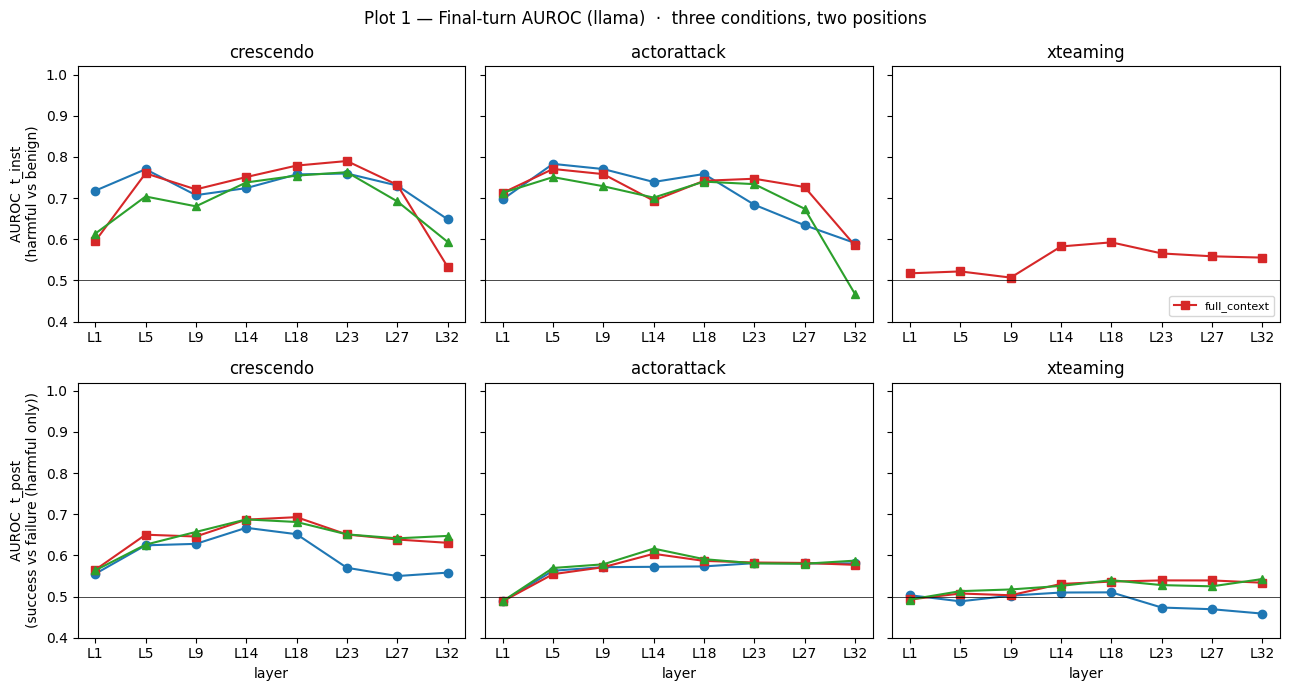

In [30]:
# Plot 1 — AUROC by layer; rows = positions, cols = frameworks; lines = conditions
def annotate_missing(ax, msg="data not available"):
    ax.text(0.5, 0.5, msg, ha="center", va="center",
            transform=ax.transAxes, fontsize=10, color="0.4")
    ax.set_xticks([]); ax.set_yticks([])

PLOT1_STYLES = (("no_context",   "C0", "o"),
                ("full_context", "C3", "s"),
                ("compressed",   "C2", "^"))

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharey=True)
for i, pos in enumerate(POSITIONS):
    sub_label = "harmful vs benign" if pos == "t_inst" else "success vs failure (harmful only)"
    for j, fw in enumerate(FRAMEWORKS):
        ax = axes[i, j]
        d = ft_auroc[(ft_auroc.position == pos) & (ft_auroc.framework == fw)]
        if d["auroc"].isna().all():
            annotate_missing(ax); ax.set_title(fw); continue
        for cond, color, marker in PLOT1_STYLES:
            d_c = (d[d.condition == cond]
                   .set_index("layer").reindex(LAYER_LABELS).reset_index())
            if d_c["auroc"].isna().all(): continue
            ax.plot(d_c.layer, d_c.auroc, marker=marker, ls="-", color=color, label=cond)
        ax.axhline(0.5, color="k", lw=0.5)
        ax.set_title(fw); ax.set_ylim(0.4, 1.02)
        if i == 1: ax.set_xlabel("layer")
    axes[i, 0].set_ylabel(f"AUROC  {pos}\n({sub_label})")
axes[0, 2].legend(loc="lower right", fontsize=8)
fig.suptitle(f"Plot 1 — Final-turn AUROC ({MODEL})  ·  three conditions, two positions")
fig.tight_layout()
fig.savefig(FIG / "plot1_final_turn_auroc.png", dpi=150)
plt.show()

In [31]:
# Table 1 — median AUROC across layers
table1 = (ft_auroc.groupby(["position", "framework", "condition"])["auroc"]
          .median().round(3))
table1 = table1.reindex(pd.MultiIndex.from_product(
    [POSITIONS, FRAMEWORKS, CONDITIONS],
    names=["position", "framework", "condition"]))
table1.to_csv(OUT / "03_table1_median_auroc.csv")
print(f"Table 1 — Median AUROC across {N_LAYERS} layers ({MODEL}):")
print(table1)

Table 1 — Median AUROC across 8 layers (llama):
position  framework    condition   
t_inst    crescendo    full_context    0.742
                       no_context      0.727
                       compressed      0.698
          actorattack  full_context    0.734
                       no_context      0.718
                       compressed      0.721
          xteaming     full_context    0.557
                       no_context        NaN
                       compressed        NaN
t_post    crescendo    full_context    0.648
                       no_context      0.597
                       compressed      0.649
          actorattack  full_context    0.579
                       no_context      0.573
                       compressed      0.580
          xteaming     full_context    0.532
                       no_context      0.495
                       compressed      0.525
Name: auroc, dtype: float64


## §4 Context effect on final-turn transfer

**Question.** What does prior history add beyond the local message at the same turn?

**Operation.** Compute `ΔAUROC = AUROC(full_context) − AUROC(no_context)` per (framework, position, layer). This is *context effect on separability*, not direction displacement — the directions are the same in both conditions.

**Plot 2** = ΔAUROC by layer × framework × position.

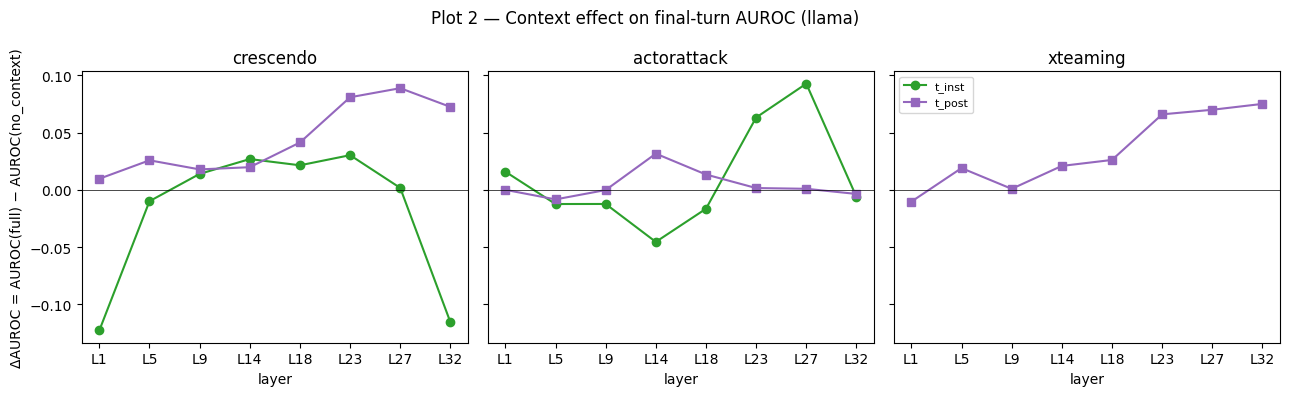

In [32]:
delta = (ft_auroc
         .pivot_table(index=["layer", "position", "framework"],
                      columns="condition", values="auroc")
         .assign(delta=lambda d: d["full_context"] - d["no_context"])
         .reset_index())
delta.to_csv(OUT / "04_context_effect.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for j, fw in enumerate(FRAMEWORKS):
    ax = axes[j]
    sub = delta[delta.framework == fw]
    if sub["delta"].isna().all():
        annotate_missing(ax); ax.set_title(fw); continue
    for pos, color, marker in (("t_inst", "C2", "o"), ("t_post", "C4", "s")):
        d = sub[sub.position == pos].set_index("layer").reindex(LAYER_LABELS).reset_index()
        ax.plot(d.layer, d["delta"], marker=marker, color=color, label=pos)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(fw); ax.set_xlabel("layer")
axes[0].set_ylabel("ΔAUROC = AUROC(full) − AUROC(no_context)")
axes[2].legend(loc="best", fontsize=8)
fig.suptitle(f"Plot 2 — Context effect on final-turn AUROC ({MODEL})")
fig.tight_layout()
fig.savefig(FIG / "plot2_context_effect.png", dpi=150)
plt.show()

## §5 Turn-resolved transfer with fixed directions

**Question.** When does the fixed single-turn direction stop working?

**Operation.** For each (framework, condition, layer, turn `k`), project WJB rows at turn `k` onto the fixed direction (`v_inst` at `t_inst`, `v_outcome[*, framework]` at `t_post`); AUROC against the position-conditional label. Conditions: `full_context` and `no_context` only — **compressed appears as a horizontal reference line**, since it has no `turn_k` structure.

**Plot 3a** = per-turn AUROC at `t_inst`. **Plot 3b** = per-turn AUROC at `t_post`.

In [33]:
def auroc_per_turn_fixed(position, condition, framework):
    """Per-turn AUROC using the fixed direction (v_inst or v_outcome)."""
    out = []
    if position == "t_inst":
        kh = ("WJB", condition, "harmful", framework)
        kb = ("WJB", condition, "benign",  framework)
        if kh not in BLOCKS or kb not in BLOCKS:
            return out
        mh, mb = BLOCKS[kh][0], BLOCKS[kb][0]
        ks = sorted(set(mh.turn_k) & set(mb.turn_k))
        for L in range(N_LAYERS):
            v = v_inst[L]
            for k in ks:
                rh = mh.index[mh.turn_k == k].to_numpy()
                rb = mb.index[mb.turn_k == k].to_numpy()
                if len(rh) == 0 or len(rb) == 0: continue
                sh = vecs(kh, "t_inst", L, rh) @ v
                sb = vecs(kb, "t_inst", L, rb) @ v
                scores = np.concatenate([sh, sb])
                labels = np.concatenate([np.ones(len(sh)), np.zeros(len(sb))]).astype(int)
                out.append({"layer": LAYER_LABELS[L], "framework": framework,
                            "condition": condition, "turn_k": int(k),
                            "auroc": roc_auc_score(labels, scores), "n": len(labels)})
    else:
        key = ("WJB", condition, "harmful", framework)
        if key not in BLOCKS:
            return out
        m = BLOCKS[key][0]
        for L in range(N_LAYERS):
            v = v_outcome.get((L, framework))
            if v is None: continue
            for k in sorted(m.turn_k.unique()):
                rows = m.index[m.turn_k == k].to_numpy()
                scores = vecs(key, "t_post", L, rows) @ v
                labels = success_mask(key, rows, AISI_WJB[framework]).astype(int)
                if len(np.unique(labels)) < 2: continue
                out.append({"layer": LAYER_LABELS[L], "framework": framework,
                            "condition": condition, "turn_k": int(k),
                            "auroc": roc_auc_score(labels, scores), "n": len(labels)})
    return out

per_turn = []
for pos in POSITIONS:
    for fw in FRAMEWORKS:
        for cond in ("no_context", "full_context"):
            per_turn.extend({"position": pos, **r}
                            for r in auroc_per_turn_fixed(pos, cond, fw))
per_turn_df = pd.DataFrame(per_turn)
per_turn_df.to_csv(OUT / "05_per_turn_auroc.csv", index=False)
print(f"per-turn AUROC rows: {len(per_turn_df)}")

per-turn AUROC rows: 680


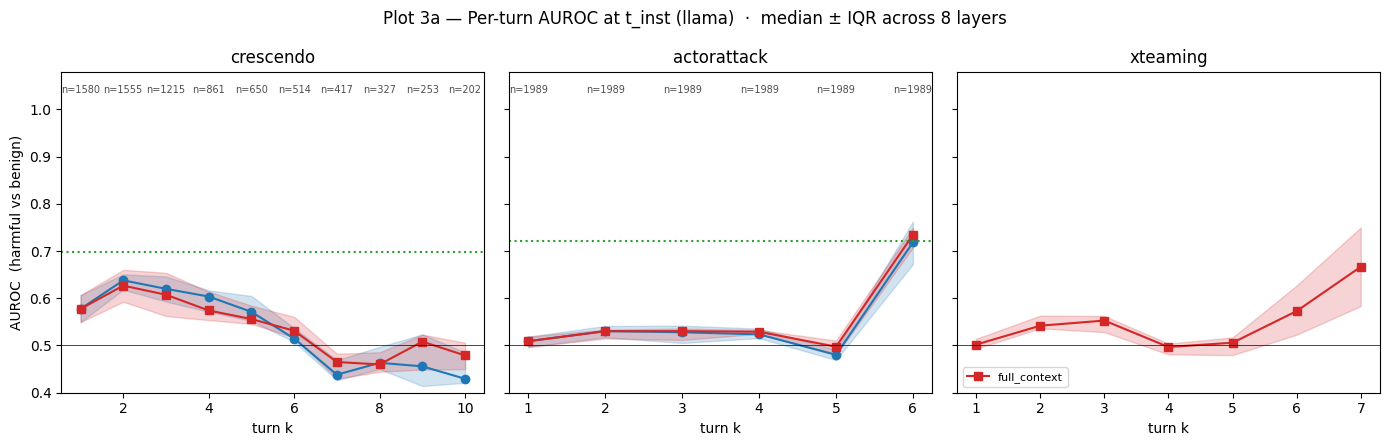

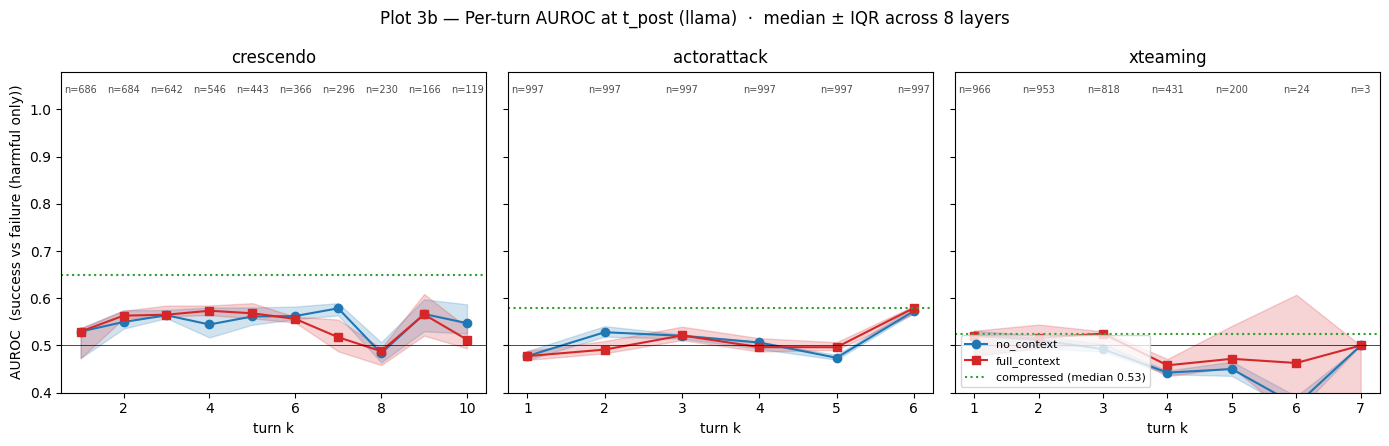

In [34]:
# Compressed reference (median across layers).
compressed_ref = (ft_auroc[ft_auroc.condition == "compressed"]
                  .groupby(["position", "framework"])["auroc"].median())

def plot_per_turn(position, sub_label, fname, plot_label):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
    sub_all = per_turn_df[per_turn_df.position == position]
    for j, fw in enumerate(FRAMEWORKS):
        ax  = axes[j]
        sub = sub_all[sub_all.framework == fw]
        if sub.empty:
            annotate_missing(ax); ax.set_title(fw); continue
        n_ref = None
        for cond, color, marker in (("no_context", "C0", "o"), ("full_context", "C3", "s")):
            d = sub[sub.condition == cond]
            if d.empty: continue
            agg = d.groupby("turn_k")["auroc"].agg(["median",
                lambda s: s.quantile(0.25), lambda s: s.quantile(0.75)])
            agg.columns = ["median", "q25", "q75"]
            agg = agg.sort_index()
            ax.plot(agg.index, agg["median"], marker=marker, color=color, label=cond)
            ax.fill_between(agg.index, agg["q25"], agg["q75"], color=color, alpha=0.2)
            if n_ref is None and cond == "no_context":
                n_ref = d.groupby("turn_k")["n"].first().sort_index()
        cref = compressed_ref.get((position, fw))
        if cref is not None and not np.isnan(cref):
            ax.axhline(cref, color="C2", lw=1.5, ls=":",
                       label=f"compressed (median {cref:.2f})")
        ax.axhline(0.5, color="k", lw=0.5)
        ax.set_title(fw); ax.set_xlabel("turn k")
        if n_ref is not None:
            ymax = 1.02
            ax.set_ylim(0.4, ymax + 0.06)
            for k, n in n_ref.items():
                ax.text(k, ymax + 0.01, f"n={int(n)}",
                        ha="center", va="bottom", fontsize=7, color="0.3")
    axes[0].set_ylabel(f"AUROC  ({sub_label})")
    axes[2].legend(loc="lower left", fontsize=8)
    fig.suptitle(f"{plot_label} — Per-turn AUROC at {position} ({MODEL})  ·  median ± IQR across {N_LAYERS} layers")
    fig.tight_layout()
    fig.savefig(FIG / fname, dpi=150)
    plt.show()

plot_per_turn("t_inst", "harmful vs benign",
              "plot3a_per_turn_auroc_t_inst.png", "Plot 3a")
plot_per_turn("t_post", "success vs failure (harmful only)",
              "plot3b_per_turn_auroc_t_post.png", "Plot 3b")

## §6 Per-turn direction displacement

**Question.** How does the harmfulness axis itself change over turns?

This is the main mechanistic analysis. Two cosines, computed only on JBB (no WJB needed):

* **§6.1 Drift from anchor:** `cos(v_pt(k), v_inst)` — how different is the per-turn axis from the single-turn anchor?
* **§6.2 Context-vs-message decomposition:** `cos(v_full(k), v_noctx(k))` — how much of the displacement is from prior history once the local message is held fixed?

### §6.1 Drift from single-turn anchor

`cos(v_pt[L, fw, cond, k], v_inst[L])` per (framework, condition, turn, layer). At `k=1` this is **not** by construction equal to anything special — it measures how the framework's framing of the very first user turn already differs from a JBB single-turn instruction.

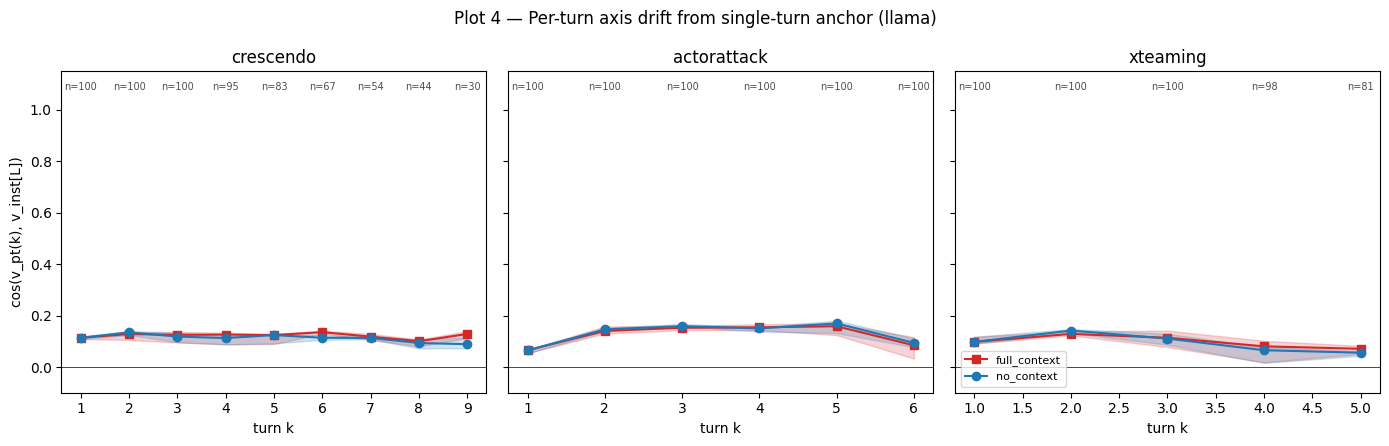

In [35]:
drift = []
for (L, fw, cond, k), v in v_pt.items():
    drift.append({"layer": LAYER_LABELS[L], "framework": fw,
                  "condition": cond, "turn_k": k,
                  "cos": float(np.dot(v, v_inst[L])),
                  "n_pairs": n_pairs_pt.get((fw, cond, k), 0)})
drift_df = pd.DataFrame(drift)
drift_df.to_csv(OUT / "06_drift.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
for j, fw in enumerate(FRAMEWORKS):
    ax  = axes[j]
    sub = drift_df[drift_df.framework == fw]
    if sub.empty:
        annotate_missing(ax); ax.set_title(fw); continue
    n_ref = None
    for cond, color, marker in (("full_context", "C3", "s"), ("no_context", "C0", "o")):
        d = sub[sub.condition == cond]
        if d.empty: continue
        agg = d.groupby("turn_k")["cos"].agg(["median",
            lambda s: s.quantile(0.25), lambda s: s.quantile(0.75)])
        agg.columns = ["median", "q25", "q75"]
        agg = agg.sort_index()
        ax.plot(agg.index, agg["median"], marker=marker, color=color, label=cond)
        ax.fill_between(agg.index, agg["q25"], agg["q75"], color=color, alpha=0.2)
        if n_ref is None and cond == "full_context":
            n_ref = d.groupby("turn_k")["n_pairs"].first().sort_index()
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(fw); ax.set_xlabel("turn k")
    ax.set_ylim(-0.1, 1.15)
    if n_ref is not None:
        for k, n in n_ref.items():
            ax.text(k, 1.07, f"n={int(n)}",
                    ha="center", va="bottom", fontsize=7, color="0.3")
axes[0].set_ylabel("cos(v_pt(k), v_inst[L])")
axes[2].legend(loc="lower left", fontsize=8)
fig.suptitle(f"Plot 4 — Per-turn axis drift from single-turn anchor ({MODEL})")
fig.tight_layout()
fig.savefig(FIG / "plot4_drift.png", dpi=150)
plt.show()

### §6.2 Context-vs-message decomposition

`cos(v_pt[L, fw, full_context, k], v_pt[L, fw, no_context, k])`. Both axes are computed at the same `k`-th user message; the only thing that differs is whether prior history is visible. Equal to **1.0 at `k=1` by construction** (no history exists yet). Below 1.0 at `k > 1` is the pure-context contribution to displacement.

Sanity — cos(v_full(1), v_noctx(1)) median across layers (expect ≈ 1.0):
framework
actorattack    0.999915
crescendo      0.999999
xteaming       1.000000
Name: cos_full_noctx, dtype: float64


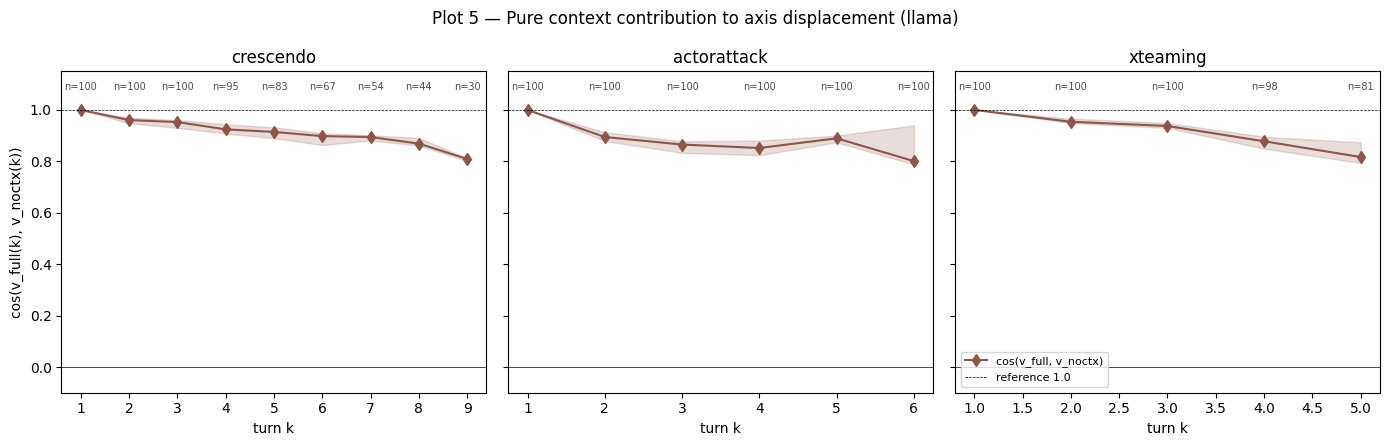

In [36]:
decomp = []
for (L, fw, cond, k), v in v_pt.items():
    if cond != "full_context":
        continue
    other = v_pt.get((L, fw, "no_context", k))
    if other is None:
        continue
    decomp.append({"layer": LAYER_LABELS[L], "framework": fw, "turn_k": k,
                   "cos_full_noctx": float(np.dot(v, other)),
                   "n_pairs": n_pairs_pt.get((fw, "full_context", k), 0)})
decomp_df = pd.DataFrame(decomp)
decomp_df.to_csv(OUT / "06_decomp.csv", index=False)

if not decomp_df.empty:
    print("Sanity — cos(v_full(1), v_noctx(1)) median across layers (expect ≈ 1.0):")
    print(decomp_df[decomp_df.turn_k == 1].groupby("framework")["cos_full_noctx"].median())

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
for j, fw in enumerate(FRAMEWORKS):
    ax  = axes[j]
    sub = decomp_df[decomp_df.framework == fw]
    if sub.empty:
        annotate_missing(ax); ax.set_title(fw); continue
    n_ref = sub.groupby("turn_k")["n_pairs"].first().sort_index()
    agg = sub.groupby("turn_k")["cos_full_noctx"].agg(["median",
        lambda s: s.quantile(0.25), lambda s: s.quantile(0.75)])
    agg.columns = ["median", "q25", "q75"]
    agg = agg.sort_index()
    ax.plot(agg.index, agg["median"], marker="d", color="C5",
            label="cos(v_full, v_noctx)")
    ax.fill_between(agg.index, agg["q25"], agg["q75"], color="C5", alpha=0.2)
    ax.axhline(1.0, color="k", lw=0.5, ls="--", label="reference 1.0")
    ax.axhline(0,   color="k", lw=0.5)
    ax.set_title(fw); ax.set_xlabel("turn k")
    ax.set_ylim(-0.1, 1.15)
    for k, n in n_ref.items():
        ax.text(k, 1.07, f"n={int(n)}",
                ha="center", va="bottom", fontsize=7, color="0.3")
axes[0].set_ylabel("cos(v_full(k), v_noctx(k))")
axes[2].legend(loc="lower left", fontsize=8)
fig.suptitle(f"Plot 5 — Pure context contribution to axis displacement ({MODEL})")
fig.tight_layout()
fig.savefig(FIG / "plot5_decomp.png", dpi=150)
plt.show()

## §7 Per-turn classifier

**Question.** Does adapting the axis recover the lost classification performance?

**Operation.** At `t_inst`, per (framework, layer, turn `k`), compare two AUROCs on WJB:
* fixed anchor: `v_inst[L]`
* adaptive turn-matched: `v_pt[L, fw, full_context, k]` (built on JBB at the matching turn)

**Plot 6** = fixed vs adaptive AUROC by turn × framework. The gap is the practical cost of using a stale single-turn axis at that turn.

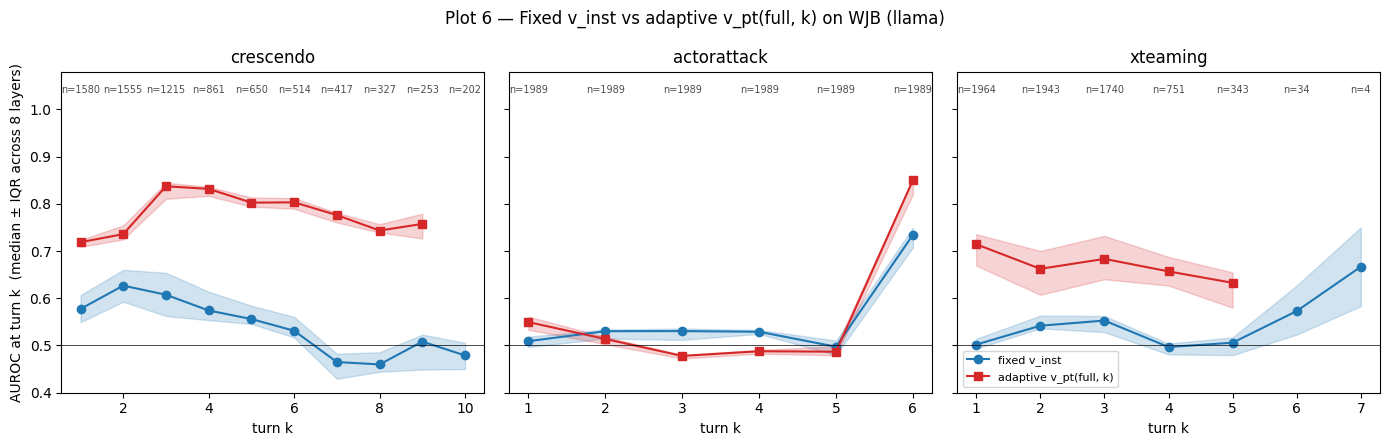

In [37]:
adaptive = []
for fw in FRAMEWORKS:
    kh = ("WJB", "full_context", "harmful", fw)
    kb = ("WJB", "full_context", "benign",  fw)
    if kh not in BLOCKS or kb not in BLOCKS:
        continue
    mh, mb = BLOCKS[kh][0], BLOCKS[kb][0]
    for k in sorted(set(mh.turn_k) & set(mb.turn_k)):
        k = int(k)
        rh = mh.index[mh.turn_k == k].to_numpy()
        rb = mb.index[mb.turn_k == k].to_numpy()
        if len(rh) == 0 or len(rb) == 0: continue
        labels = np.concatenate([np.ones(len(rh)), np.zeros(len(rb))]).astype(int)
        for L in range(N_LAYERS):
            v_st = v_inst[L]
            scores_anc = np.concatenate([
                vecs(kh, "t_inst", L, rh) @ v_st,
                vecs(kb, "t_inst", L, rb) @ v_st])
            auc_anc = roc_auc_score(labels, scores_anc)
            v_ad = v_pt.get((L, fw, "full_context", k))
            if v_ad is None:
                auc_ad = np.nan
            else:
                scores_ad = np.concatenate([
                    vecs(kh, "t_inst", L, rh) @ v_ad,
                    vecs(kb, "t_inst", L, rb) @ v_ad])
                auc_ad = roc_auc_score(labels, scores_ad)
            adaptive.append({"layer": LAYER_LABELS[L], "framework": fw, "turn_k": k,
                             "auc_fixed": auc_anc, "auc_adaptive": auc_ad,
                             "n": len(labels)})
adaptive_df = pd.DataFrame(adaptive)
adaptive_df.to_csv(OUT / "07_fixed_vs_adaptive.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
for j, fw in enumerate(FRAMEWORKS):
    ax  = axes[j]
    sub = adaptive_df[adaptive_df.framework == fw]
    if sub.empty:
        annotate_missing(ax); ax.set_title(fw); continue
    n_ref = sub.groupby("turn_k")["n"].first().sort_index()
    for col, color, marker, label in (("auc_fixed",    "C0", "o", "fixed v_inst"),
                                       ("auc_adaptive", "C3", "s", "adaptive v_pt(full, k)")):
        agg = sub.groupby("turn_k")[col].agg(["median",
            lambda s: s.quantile(0.25), lambda s: s.quantile(0.75)])
        agg.columns = ["median", "q25", "q75"]
        agg = agg.sort_index()
        if agg["median"].isna().all(): continue
        ax.plot(agg.index, agg["median"], marker=marker, color=color, label=label)
        ax.fill_between(agg.index, agg["q25"], agg["q75"], color=color, alpha=0.2)
    ax.axhline(0.5, color="k", lw=0.5)
    ax.set_title(fw); ax.set_xlabel("turn k")
    ax.set_ylim(0.4, 1.08)
    for k, n in n_ref.items():
        ax.text(k, 1.03, f"n={int(n)}",
                ha="center", va="bottom", fontsize=7, color="0.3")
axes[0].set_ylabel(f"AUROC at turn k  (median ± IQR across {N_LAYERS} layers)")
axes[2].legend(loc="lower left", fontsize=8)
fig.suptitle(f"Plot 6 — Fixed v_inst vs adaptive v_pt(full, k) on WJB ({MODEL})")
fig.tight_layout()
fig.savefig(FIG / "plot6_fixed_vs_adaptive.png", dpi=150)
plt.show()

## §8 Linear vs nonlinear recoverability

**Question.** Is the remaining signal linearly available, or does a more flexible model recover hidden structure?

**Operation.** Three classifiers per (layer, position, framework, condition):
* **M1** — logistic regression on the 1-D projection onto the position-conditional direction (`v_inst` at `t_inst`, `v_outcome` at `t_post`).
* **M2** — L2 logistic regression (`C=0.1`) on the standardized full hidden state.
* **M3** — small MLP (one hidden layer of 128 ReLU units, `alpha=1e-3`, early stopping on a 10% validation slice; mean ± std over three random seeds).

**Train / test:**
* `t_inst`: train on JBB single-turn (harmful/benign), test on WJB final-turn (harmful/benign).
* `t_post`: train on JBB full-context final-turn harmful (success/failure), test on WJB final-turn harmful (success/failure).

Test side runs under all three conditions. **Plot 7** shows M1/M2/M3 by layer for `full_context`; **Table 2** gives the median across layers for all three conditions.

In [38]:
def trainset(position, layer_idx, framework):
    if position == "t_inst":
        Xh = vecs(("JBB", "single_turn", "harmful", None), "t_inst", layer_idx)
        Xb = vecs(("JBB", "single_turn", "benign",  None), "t_inst", layer_idx)
        X  = np.concatenate([Xh, Xb])
        y  = np.concatenate([np.ones(len(Xh)), np.zeros(len(Xb))]).astype(int)
        return X, y
    info = JBB_FINAL.get(framework)
    if info is None:
        return None, None
    X = vecs(info["key"], "t_post", layer_idx, info["rows"])
    y = info["succ"].astype(int)
    return X, y

def testset(position, layer_idx, framework, condition):
    if position == "t_inst":
        kh = ("WJB", condition, "harmful", framework)
        kb = ("WJB", condition, "benign",  framework)
        if kh not in BLOCKS or kb not in BLOCKS: return None, None
        rh = final_turn_rows(kh); rb = final_turn_rows(kb)
        Xh = vecs(kh, "t_inst", layer_idx, rh)
        Xb = vecs(kb, "t_inst", layer_idx, rb)
        X  = np.concatenate([Xh, Xb])
        y  = np.concatenate([np.ones(len(Xh)), np.zeros(len(Xb))]).astype(int)
        return X, y
    key = ("WJB", condition, "harmful", framework)
    if key not in BLOCKS: return None, None
    rows = final_turn_rows(key)
    X = vecs(key, "t_post", layer_idx, rows)
    y = success_mask(key, rows, AISI_WJB[framework]).astype(int)
    return X, y

def fit_three(layer_idx, position, framework, condition):
    X_tr, y_tr = trainset(position, layer_idx, framework)
    X_te, y_te = testset (position, layer_idx, framework, condition)
    if X_tr is None or X_te is None or len(np.unique(y_te)) < 2:
        return (np.nan,) * 4
    v = v_inst[layer_idx] if position == "t_inst" else v_outcome.get((layer_idx, framework))
    if v is None:
        return (np.nan,) * 4

    s_tr = (X_tr @ v).reshape(-1, 1); s_te = (X_te @ v).reshape(-1, 1)
    m1   = LogisticRegression(max_iter=2000).fit(s_tr, y_tr)
    auc1 = roc_auc_score(y_te, m1.predict_proba(s_te)[:, 1])

    sc   = StandardScaler().fit(X_tr)
    m2   = LogisticRegression(C=0.1, max_iter=2000).fit(sc.transform(X_tr), y_tr)
    auc2 = roc_auc_score(y_te, m2.predict_proba(sc.transform(X_te))[:, 1])

    aucs3 = []
    for seed in (0, 1, 2):
        sc3 = StandardScaler().fit(X_tr)
        m3  = MLPClassifier(hidden_layer_sizes=(128,), activation="relu",
                            alpha=1e-3, max_iter=300, early_stopping=True,
                            validation_fraction=0.1, random_state=seed)
        m3.fit(sc3.transform(X_tr), y_tr)
        aucs3.append(roc_auc_score(y_te, m3.predict_proba(sc3.transform(X_te))[:, 1]))
    return auc1, auc2, float(np.mean(aucs3)), float(np.std(aucs3))

probe_rows = []
for L in range(N_LAYERS):
    for pos in POSITIONS:
        for fw in FRAMEWORKS:
            for cond in CONDITIONS:
                a1, a2, a3, a3s = fit_three(L, pos, fw, cond)
                probe_rows.append({"layer": LAYER_LABELS[L], "position": pos,
                                   "framework": fw, "condition": cond,
                                   "M1": a1, "M2": a2,
                                   "M3_mean": a3, "M3_std": a3s})
probe_df = pd.DataFrame(probe_rows)
probe_df.to_csv(OUT / "08_probes.csv", index=False)
print(f"probe rows: {len(probe_df)}")

probe rows: 144


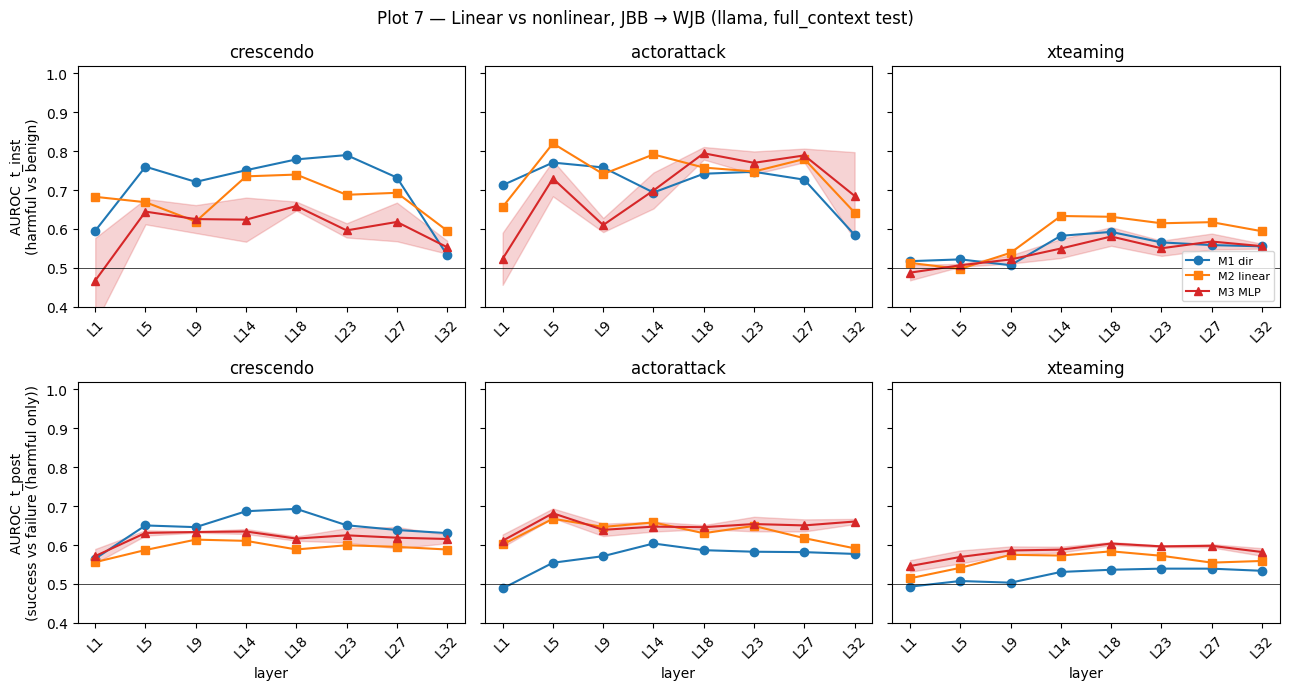

Table 2 — Median AUROC across 8 layers (llama):
                                      M1     M2  M3_mean
position framework   condition                          
t_inst   crescendo   full_context  0.742  0.685    0.621
                     no_context    0.727  0.695    0.617
                     compressed    0.698  0.652    0.568
         actorattack full_context  0.734  0.753    0.714
                     no_context    0.718  0.752    0.682
                     compressed    0.721  0.727    0.666
         xteaming    full_context  0.557  0.604    0.550
                     no_context      NaN    NaN      NaN
                     compressed      NaN    NaN      NaN
t_post   crescendo   full_context  0.648  0.592    0.622
                     no_context    0.597  0.556    0.606
                     compressed    0.649  0.609    0.629
         actorattack full_context  0.579  0.638    0.649
                     no_context    0.573  0.536    0.577
                     compressed    0.580

In [39]:
# Plot 7 — M1 / M2 / M3 by layer, full_context test side
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharey=True)
for i, pos in enumerate(POSITIONS):
    sub_label = "harmful vs benign" if pos == "t_inst" else "success vs failure (harmful only)"
    for j, fw in enumerate(FRAMEWORKS):
        ax = axes[i, j]
        d = probe_df[(probe_df.position == pos) & (probe_df.framework == fw)
                     & (probe_df.condition == "full_context")]
        if d[["M1", "M2", "M3_mean"]].isna().all().all():
            annotate_missing(ax); ax.set_title(fw); continue
        d = d.set_index("layer").reindex(LAYER_LABELS).reset_index()
        x = np.arange(len(d))
        ax.plot(x, d.M1,      "o-", color="C0", label="M1 dir")
        ax.plot(x, d.M2,      "s-", color="C1", label="M2 linear")
        ax.plot(x, d.M3_mean, "^-", color="C3", label="M3 MLP")
        ax.fill_between(x, d.M3_mean - d.M3_std, d.M3_mean + d.M3_std,
                        color="C3", alpha=0.2)
        ax.set_xticks(x); ax.set_xticklabels(d.layer, rotation=45)
        ax.set_title(fw); ax.set_ylim(0.4, 1.02); ax.axhline(0.5, color="k", lw=0.5)
        if i == 1: ax.set_xlabel("layer")
    axes[i, 0].set_ylabel(f"AUROC  {pos}\n({sub_label})")
axes[0, 2].legend(loc="lower right", fontsize=8)
fig.suptitle(f"Plot 7 — Linear vs nonlinear, JBB → WJB ({MODEL}, full_context test)")
fig.tight_layout()
fig.savefig(FIG / "plot7_probes_full_context.png", dpi=150)
plt.show()

# Table 2 — median across layers, all three conditions
table2 = (probe_df.groupby(["position", "framework", "condition"])
          [["M1", "M2", "M3_mean"]].median().round(3))
table2 = table2.reindex(pd.MultiIndex.from_product(
    [POSITIONS, FRAMEWORKS, CONDITIONS],
    names=["position", "framework", "condition"]))
table2.to_csv(OUT / "08_table2_probe_medians.csv")
print(f"Table 2 — Median AUROC across {N_LAYERS} layers ({MODEL}):")
print(table2)

## §9 Cross-framework transfer

**Question.** Is the readout shared across attack frameworks, or framework-specific?

**Operation.** For each (layer, position, train_fw, test_fw, condition), train an L2 linear probe on JBB[train_fw] full-context final-turn states (note: full-context, not single-turn — apples-to-apples within-framework diagonal) and test on WJB[test_fw] final-turn states under the chosen test condition.

**Plot 8** = 3×3 cross-framework transfer heatmap for `full_context` (the main result). Appendix heatmaps cover `no_context` and `compressed`.

In [40]:
def xfw_train_xy(position, layer_idx, train_fw):
    if position == "t_inst":
        kh = ("JBB", "full_context", "harmful", train_fw)
        kb = ("JBB", "full_context", "benign",  train_fw)
        if kh not in BLOCKS or kb not in BLOCKS: return None, None
        rh = final_turn_rows(kh); rb = final_turn_rows(kb)
        Xh = vecs(kh, "t_inst", layer_idx, rh)
        Xb = vecs(kb, "t_inst", layer_idx, rb)
        X = np.concatenate([Xh, Xb])
        y = np.concatenate([np.ones(len(Xh)), np.zeros(len(Xb))]).astype(int)
        return X, y
    info = JBB_FINAL.get(train_fw)
    if info is None: return None, None
    X = vecs(info["key"], "t_post", layer_idx, info["rows"])
    y = info["succ"].astype(int)
    return X, y

def xfw_test_xy(position, layer_idx, test_fw, condition):
    if position == "t_inst":
        kh = ("WJB", condition, "harmful", test_fw)
        kb = ("WJB", condition, "benign",  test_fw)
        if kh not in BLOCKS or kb not in BLOCKS: return None, None
        rh = final_turn_rows(kh); rb = final_turn_rows(kb)
        Xh = vecs(kh, "t_inst", layer_idx, rh)
        Xb = vecs(kb, "t_inst", layer_idx, rb)
        X = np.concatenate([Xh, Xb])
        y = np.concatenate([np.ones(len(Xh)), np.zeros(len(Xb))]).astype(int)
        return X, y
    key = ("WJB", condition, "harmful", test_fw)
    if key not in BLOCKS: return None, None
    rows = final_turn_rows(key)
    X = vecs(key, "t_post", layer_idx, rows)
    y = success_mask(key, rows, AISI_WJB[test_fw]).astype(int)
    return X, y

def xfw_auc(L, position, train_fw, test_fw, condition):
    X_tr, y_tr = xfw_train_xy(position, L, train_fw)
    X_te, y_te = xfw_test_xy (position, L, test_fw, condition)
    if X_tr is None or X_te is None or len(np.unique(y_te)) < 2:
        return np.nan
    sc = StandardScaler().fit(X_tr)
    m  = LogisticRegression(C=0.1, max_iter=2000).fit(sc.transform(X_tr), y_tr)
    return roc_auc_score(y_te, m.predict_proba(sc.transform(X_te))[:, 1])

xfw_rows = []
for L in range(N_LAYERS):
    for pos in POSITIONS:
        for cond in CONDITIONS:
            for tr in FRAMEWORKS:
                for te in FRAMEWORKS:
                    xfw_rows.append({"layer": LAYER_LABELS[L], "position": pos,
                                     "condition": cond, "train_fw": tr, "test_fw": te,
                                     "auroc": xfw_auc(L, pos, tr, te, cond)})
xfw_df = pd.DataFrame(xfw_rows)
xfw_df.to_csv(OUT / "09_cross_framework.csv", index=False)

xfw_med = (xfw_df.groupby(["position", "condition", "train_fw", "test_fw"])["auroc"]
           .median().unstack("test_fw")
           .reindex(FRAMEWORKS, level="train_fw")
           .reindex(FRAMEWORKS, axis=1))
print(f"cross-framework matrix entries: {len(xfw_df)}")

cross-framework matrix entries: 432


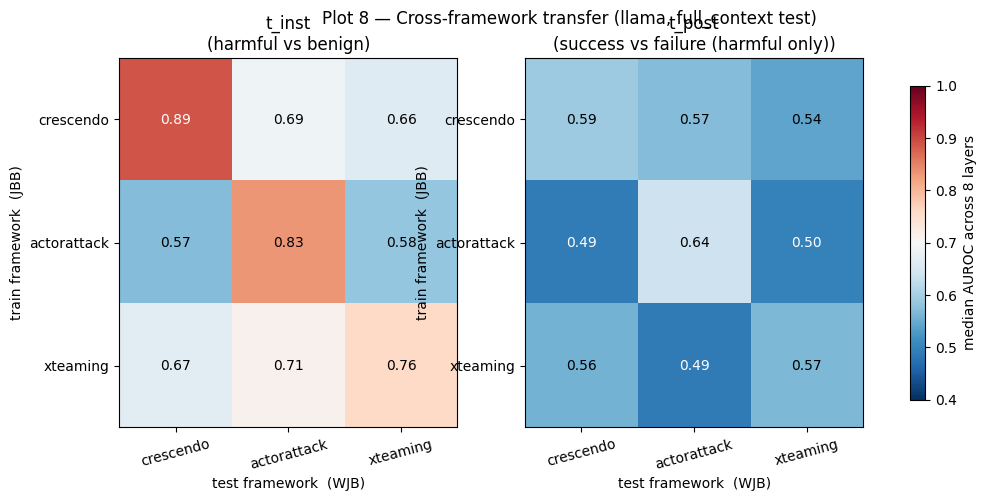

In [41]:
def plot_xfw_matrix(position, condition, ax, title):
    try:
        mat = (xfw_med.loc[(position, condition)]
               .reindex(FRAMEWORKS).reindex(FRAMEWORKS, axis=1).values)
    except KeyError:
        annotate_missing(ax, "no data"); ax.set_title(title); return None
    im = ax.imshow(mat, vmin=0.4, vmax=1.0, cmap="RdBu_r", aspect="auto")
    for r in range(len(FRAMEWORKS)):
        for c in range(len(FRAMEWORKS)):
            v = mat[r, c]
            ax.text(c, r, "—" if np.isnan(v) else f"{v:.2f}",
                    ha="center", va="center",
                    color="white" if (not np.isnan(v) and abs(v - 0.7) > 0.18) else "black",
                    fontsize=10)
    ax.set_xticks(range(len(FRAMEWORKS))); ax.set_xticklabels(FRAMEWORKS, rotation=15)
    ax.set_yticks(range(len(FRAMEWORKS))); ax.set_yticklabels(FRAMEWORKS)
    ax.set_xlabel("test framework  (WJB)")
    ax.set_ylabel("train framework  (JBB)")
    ax.set_title(title)
    return im

# Plot 8 — main: full_context, two positions side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
ims = []
for ax, pos in zip(axes, POSITIONS):
    sub = "harmful vs benign" if pos == "t_inst" else "success vs failure (harmful only)"
    im = plot_xfw_matrix(pos, "full_context", ax, f"{pos}\n({sub})")
    if im is not None: ims.append(im)
if ims:
    fig.colorbar(ims[-1], ax=axes.ravel().tolist(),
                 label=f"median AUROC across {N_LAYERS} layers", shrink=0.85)
fig.suptitle(f"Plot 8 — Cross-framework transfer ({MODEL}, full_context test)")
fig.savefig(FIG / "plot8_cross_framework_full.png", dpi=150, bbox_inches="tight")
plt.show()

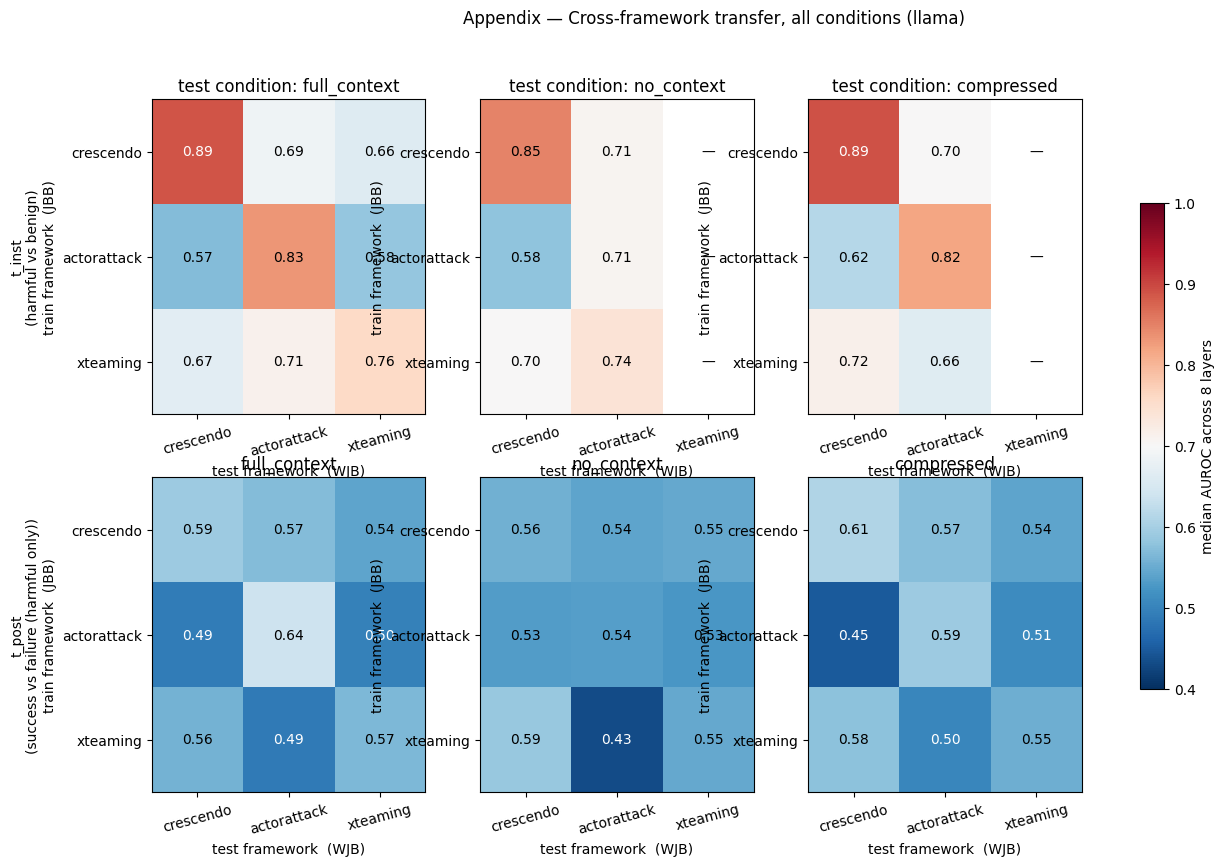

In [42]:
# Appendix — all three conditions × two positions
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
last_im = None
for i, pos in enumerate(POSITIONS):
    sub = "harmful vs benign" if pos == "t_inst" else "success vs failure (harmful only)"
    for j, cond in enumerate(CONDITIONS):
        ax = axes[i, j]
        title = f"test condition: {cond}" if i == 0 else cond
        im = plot_xfw_matrix(pos, cond, ax, title)
        if im is not None: last_im = im
        if j == 0:
            ax.set_ylabel(f"{pos}\n({sub})\ntrain framework  (JBB)")
if last_im is not None:
    fig.colorbar(last_im, ax=axes.ravel().tolist(),
                 label=f"median AUROC across {N_LAYERS} layers", shrink=0.7)
fig.suptitle(f"Appendix — Cross-framework transfer, all conditions ({MODEL})")
fig.savefig(FIG / "plot8_appendix_all_conditions.png", dpi=150, bbox_inches="tight")
plt.show()

## §10 Compressed control

**Question.** Is multi-turn delivery itself the main source of detection failure?

The compressed condition is a **control**, not a separate experiment. It packs each multi-turn conversation into a single semantically-equivalent user message. If `compressed ≈ full_context` on the same direction, then the same content delivered single-turn produces the same readout as the multi-turn version — multi-turn delivery is *not* what suppresses detection.

Compressed is read against `full_context` and `no_context` from §3 (final-turn projection), §8 (linear vs nonlinear), and §9 (cross-framework). This section consolidates those views.

In [43]:
# 10.1 Final-turn projection: compressed vs full and no_context gaps
gap = (ft_auroc.pivot_table(index=["position", "framework", "layer"],
                            columns="condition", values="auroc")
       .reset_index())
if "full_context" in gap.columns and "compressed" in gap.columns:
    gap["full_minus_compressed"]    = gap["full_context"] - gap["compressed"]
if "no_context" in gap.columns and "compressed" in gap.columns:
    gap["compressed_minus_noctx"]   = gap["compressed"] - gap["no_context"]
gap.to_csv(OUT / "10_compressed_gap.csv", index=False)

print(f"Compressed control — final-turn gaps, median across {N_LAYERS} layers ({MODEL}):")
gap_summary_cols = [c for c in ("full_minus_compressed", "compressed_minus_noctx")
                    if c in gap.columns]
if gap_summary_cols:
    print(gap.groupby(["position", "framework"])[gap_summary_cols].median().round(3))

# 10.2 Probe-level comparison (M1/M2/M3 across conditions)
print(f"\nProbe-level comparison ({MODEL}, median across {N_LAYERS} layers):")
print(probe_df.groupby(["position", "framework", "condition"])
      [["M1", "M2", "M3_mean"]].median().round(3)
      .reindex(pd.MultiIndex.from_product([POSITIONS, FRAMEWORKS, CONDITIONS],
                                           names=["position", "framework", "condition"])))

Compressed control — final-turn gaps, median across 8 layers (llama):
condition             full_minus_compressed  compressed_minus_noctx
position framework                                                 
t_inst   actorattack                  0.016                  -0.025
         crescendo                    0.026                  -0.033
         xteaming                       NaN                     NaN
t_post   actorattack                 -0.006                   0.007
         crescendo                   -0.000                   0.029
         xteaming                    -0.002                   0.027

Probe-level comparison (llama, median across 8 layers):
                                      M1     M2  M3_mean
position framework   condition                          
t_inst   crescendo   full_context  0.742  0.685    0.621
                     no_context    0.727  0.695    0.617
                     compressed    0.698  0.652    0.568
         actorattack full_context  0.734  0.

## §11 Cross-model replication

This notebook is parameterized by the `MODEL` constant in §0. To replicate the analysis across the three target models, set `MODEL` to each of `"llama"`, `"qwen"`, `"gemma"` in turn and re-run the entire notebook. Results are written to `results/clean_pipeline/{MODEL}/` and figures to `figures/clean_pipeline/{MODEL}/`, so each run produces an isolated set of artefacts.

Direction objects are **not** portable across models (different hidden dimensions, different tokenizers, different chat templates). The cross-model claim must therefore be made at the *behaviour-of-the-pipeline* level, not at the direction level.

After running the notebook for all three models, aggregate the saved CSVs to compare:

* final-turn AUROC patterns (`03_final_turn_auroc.csv`, `03_table1_median_auroc.csv`)
* context-effect ΔAUROC (`04_context_effect.csv`)
* per-turn drift and decomposition (`06_drift.csv`, `06_decomp.csv`)
* fixed-vs-adaptive AUROC (`07_fixed_vs_adaptive.csv`)
* MLP-vs-linear gaps (`08_table2_probe_medians.csv`)
* cross-framework matrix shape (`09_cross_framework.csv`)

The aggregation is intentionally left out of this notebook — it produces summary tables and a multi-panel comparison figure that lives in a separate `cross_model_summary` notebook so this one stays single-model and re-runnable.

In [45]:
print(f"=== Done — {MODEL} ===")
print(f"figures →  {FIG}")
print(f"results →  {OUT}")
print()
print("Saved CSVs:")
for p in sorted(OUT.glob("*.csv")):
    print(f"  {p.name}")
print()
print("Saved figures:")
for p in sorted(FIG.glob("*.png")):
    print(f"  {p.name}")

=== Done — llama ===
figures →  /Users/lisahusieva/Desktop/multi-turn-rep-eng/figures/clean_pipeline/llama
results →  /Users/lisahusieva/Desktop/multi-turn-rep-eng/results/clean_pipeline/llama

Saved CSVs:
  01_block_counts.csv
  01_final_turn_counts.csv
  01_per_turn_counts.csv
  01_t_post_balance.csv
  01_topic_pair_counts.csv
  03_final_turn_auroc.csv
  03_table1_median_auroc.csv
  04_context_effect.csv
  05_per_turn_auroc.csv
  06_decomp.csv
  06_drift.csv
  07_fixed_vs_adaptive.csv
  08_probes.csv
  08_table2_probe_medians.csv
  09_cross_framework.csv
  10_compressed_gap.csv

Saved figures:
  plot1_final_turn_auroc.png
  plot2_context_effect.png
  plot3a_per_turn_auroc_t_inst.png
  plot3b_per_turn_auroc_t_post.png
  plot4_drift.png
  plot5_decomp.png
  plot6_fixed_vs_adaptive.png
  plot7_probes_full_context.png
  plot8_appendix_all_conditions.png
  plot8_cross_framework_full.png
